Made by: Thai Vang, Angel Vasquez

Dataset from: https://www.kaggle.com/datasets/gkalpolukcu/knn-algorithm-dataset


In [ ]:
#Importing Libraries
from sklearn.metrics._plot.confusion_matrix import confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier     # The KNN algorithm itself
from sklearn.metrics import(
    accuracy_score,
    classification_report,
    confusion_matrix
)

print('='*60)
print(" KNN #1: Tumor dataset")
print('='*60)
print()

 KNN #1: Tumor dataset



In [ ]:
df=pd.read_csv('KNNAlgorithmDataset.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
#Dropping Unnamed Column
df.drop('Unnamed: 32', axis=1, inplace=True)
df.drop('id', axis=1, inplace=True)
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
print("STEP 2: Exploring the Data")
print("-" * 40)
print("Average values of Tumor diagnosis:")
print(df.groupby('diagnosis').mean().round(1))
print()

STEP 2: Exploring the Data
----------------------------------------
Average values of Tumor diagnosis:
           radius_mean  texture_mean  perimeter_mean  area_mean  \
diagnosis                                                         
B                 12.1          17.9            78.1      462.8   
M                 17.5          21.6           115.4      978.4   

           smoothness_mean  compactness_mean  concavity_mean  \
diagnosis                                                      
B                      0.1               0.1             0.0   
M                      0.1               0.1             0.2   

           concave points_mean  symmetry_mean  fractal_dimension_mean  ...  \
diagnosis                                                              ...   
B                          0.0            0.2                     0.1  ...   
M                          0.1            0.2                     0.1  ...   

           radius_worst  texture_worst  perimeter_worst  a

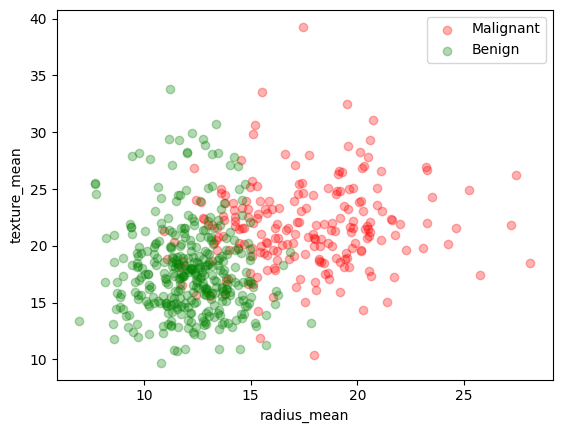

In [ ]:
#Step 3: Exploring the Data
M = df[df.diagnosis == "M"]
B = df[df.diagnosis == "B"]

# Creating the Scatter plot
plt.scatter(M.radius_mean,M.texture_mean,color="red",label="Malignant",alpha= 0.3)
plt.scatter(B.radius_mean,B.texture_mean,color="green",label="Benign",alpha= 0.3)
plt.xlabel("radius_mean")
plt.ylabel("texture_mean")
plt.legend()
plt.show()

In [ ]:
#Step 4: Preparing the Data
X = df.drop('diagnosis',axis=1)
y = df['diagnosis']

print(f"features (x) shape: {X.shape}")
print(f"labels (y) shape: {y.shape}")
print()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print()

features (x) shape: (569, 30)
labels (y) shape: (569,)

Training samples: 455
Testing samples: 114



In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Step 5: Building and Training KNN Model
----------------------------------------
Overall Accuracy: 95.61%

Classification Report:
              precision    recall  f1-score   support

           B       0.95      0.99      0.97        72
           M       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



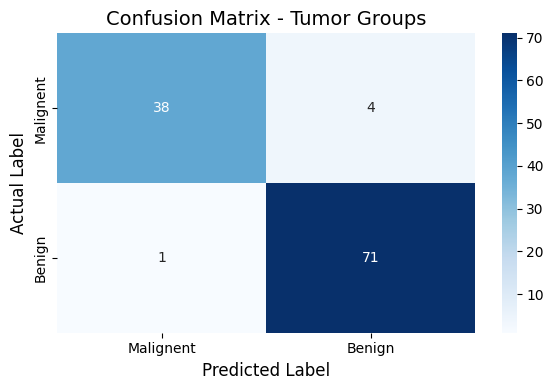

In [ ]:
#Step 5: Building and Training KNN Model
print("Step 5: Building and Training KNN Model")
print("-" * 40)

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)

#Make predictions
y_pred = knn.predict(X_test_scaled)

#Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy:.2%}")
print()

#Classification
print("Classification Report:")
print(classification_report(y_test, y_pred))

#Confusion Matrix
cm = confusion_matrix(
    y_test, y_pred,
    labels=['M','B']
)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Malignent', 'Benign'],
    yticklabels=['Malignent', 'Benign']
)

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.title('Confusion Matrix - Tumor Groups', fontsize=14)
plt.tight_layout()
plt.show()

Step 6: Finding the Best K with Cross-Validation
----------------------------------------
  K= 1 -> CV Accuracy = 94.73% (+-1.46%)
  K= 5 -> CV Accuracy = 96.26% (+-2.37%)
  K=10 -> CV Accuracy = 96.04% (+-1.79%)
  K=15 -> CV Accuracy = 96.04% (+-1.79%)
  K=20 -> CV Accuracy = 95.60% (+-1.84%)
  K=25 -> CV Accuracy = 95.38% (+-1.89%)
  K=30 -> CV Accuracy = 95.38% (+-1.89%)



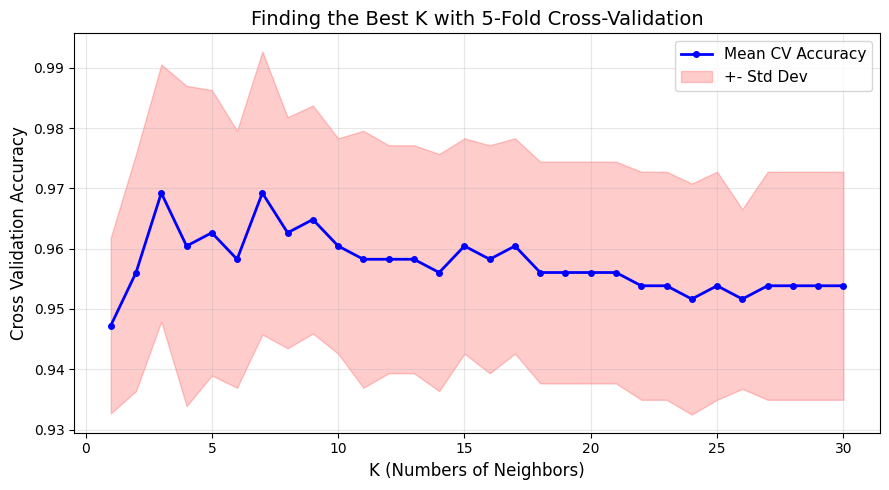

 __ Best K: 3
 __ Best CV Accuracy: 96.92%



In [ ]:
print("Step 6: Finding the Best K with Cross-Validation")
print("-"*40)

#Testing K from 1 - 30
k_range = range(1,31)

#Storing the mean CV accuracy and std of the CV accuracy
cv_means = []
cv_stds=[]

for k in k_range:
  #Creating model with this K
  model = KNeighborsClassifier(n_neighbors=k)

  #Running 5-fold cross validation on the training data
  scores = cross_val_score(
      model,
      X_train_scaled,
      y_train,
      cv=5,
      scoring='accuracy'
  )
  #Storing the mean and std dev
  cv_means.append(scores.mean())
  cv_stds.append(scores.std())

  #Printing the progress every 5 steps
  if k % 5 == 0 or k ==1:
    print(f"  K={k:2d} -> CV Accuracy = {scores.mean():.2%} (+-{scores.std():.2%})")

print()

#Plotting the Results
plt.figure(figsize=(9,5))

#Covert to numpy arrays for easy math
cv_means =np.array(cv_means)
cv_stds=np.array(cv_stds)
k_list=list(k_range)

#Main line (mean accuracy)
plt.plot(k_list, cv_means, marker='o', color='blue', linewidth=2, markersize=4, label='Mean CV Accuracy')

#Shaded Region (+1 standard deviation)
plt.fill_between(
    k_list,
    cv_means - cv_stds,
    cv_means + cv_stds,
    alpha=0.2,
    color='red',
    label='+- Std Dev'
)

plt.xlabel('K (Numbers of Neighbors)', fontsize=12)
plt.ylabel('Cross Validation Accuracy', fontsize=12)
plt.title('Finding the Best K with 5-Fold Cross-Validation', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#Find the Best K
best_k = k_list[np.argmax(cv_means)]
best_cv_accuracy = cv_means.max()

print(f" __ Best K: {best_k}")
print(f" __ Best CV Accuracy: {best_cv_accuracy:.2%}")
print()

In [ ]:
print("Step 7: Final Evaluation with Best K")

#Retrain with best K
final_model=KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train_scaled, y_train)

#Final predictions on the test set
y_pred_final = final_model.predict(X_test_scaled)

#Final Accuracy
final_accuracy = accuracy_score(y_test, y_pred_final)
print(f"Final Accuracy (K={best_k}): {final_accuracy:.2%}")
print()

#Final Report
print("Final Classification Report:")
print(classification_report(y_pred, y_pred_final))

Step 7: Final Evaluation with Best K
Final Accuracy (K=3): 93.86%

Final Classification Report:
              precision    recall  f1-score   support

           B       0.97      1.00      0.99        75
           M       1.00      0.95      0.97        39

    accuracy                           0.98       114
   macro avg       0.99      0.97      0.98       114
weighted avg       0.98      0.98      0.98       114



In [ ]:
print("Step 8: Predicting New Tumors")
print("-" * 40)

#New Patient with potential tumor
new_diagnosis = pd.DataFrame({
    'radius_mean': [17.99],
    'texture_mean': [10.38],
    'perimeter_mean': [122.8],
    'area_mean': [1001],
    'smoothness_mean': [0.1184],
    'compactness_mean': [0.2776],
    'concavity_mean': [0.3001],
    'concave points_mean': [0.1471],
    'symmetry_mean': [0.2419],
    'fractal_dimension_mean': [0.07871],
    'radius_se': [1.095],
    'texture_se': [0.9053],
    'perimeter_se': [8.589],
    'area_se': [153.4],
    'smoothness_se': [0.006399],
    'compactness_se': [0.04904],
    'concavity_se':[0.05373],
    'concave points_se': [0.01587],
    'symmetry_se': [0.03003],
    'fractal_dimension_se':[0.2131],
    'radius_worst': [25.38],
    'texture_worst': [23.41],
    'perimeter_worst': [158.8],
    'area_worst': [3001],
    'smoothness_worst': [0.1622],
    'compactness_worst': [0.6656],
    'concavity_worst': [0.7929],
    'concave points_worst': [0.09779],
    'symmetry_worst': [0.5192],
    'fractal_dimension_worst': [0.568]
})

print("New Patient Data:")
print()

new_scaled=scaler.transform(new_diagnosis)

predictions = final_model.predict(new_scaled)
probabilities = final_model.predict_proba(new_scaled)

class_labels = final_model.classes_
for i in range(len(new_diagnosis)):
  print(f"Patient#{i+1}:")
  print(f"  Predicted Diagnosis: {predictions[i]}")
  print(f"  Confidence breakdown:")

  for cls, prob in zip(class_labels, probabilities[i]):
      #Visual bar to make probabilities easy to read
      bar_length = int(prob * 25)
      bar = '█' * bar_length + '░' * (25 - bar_length)
      print(f"  {cls:8s} {bar} {prob:6.1%}")
      print()

  print()


Step 8: Predicting New Tumors
----------------------------------------
New Patient Data:

Patient#1:
  Predicted Diagnosis: B
  Confidence breakdown:
  B        █████████████████████████ 100.0%

  M        ░░░░░░░░░░░░░░░░░░░░░░░░░   0.0%




This code builds a K-Nearest Neighbors (KNN) machine learning model to classify breast tumors as malignant (M) or benign (B) using a dataset loaded from a CSV file. It begins by importing libraries for data processing, visualization, and machine learning, then loads the dataset and removes unnecessary columns such as the ID field and an unnamed column. The program explores the dataset by calculating average tumor measurements by diagnosis and visualizes two tumor features using a scatter plot to show how malignant and benign tumors differ. The dataset is then split into features and labels, followed by a train-test split, and the features are standardized using a StandardScaler to ensure that all variables contribute equally to the distance calculations used by KNN. A KNN model with seven neighbors is trained on the scaled training data, and its performance is evaluated using accuracy, a classification report, and a confusion matrix visualized with a heatmap.

Later on the code also searches for the best value of K (number of neighbors) by testing values from 1 to 30 using 5-fold cross-validation and plotting the mean accuracy with its standard deviation to visualize how model performance changes with different K values. The optimal K is selected based on the highest cross-validation accuracy, and the model is retrained using this best value to produce a final evaluation on the test dataset. Finally, the program demonstrates how the trained model can be used for prediction by inputting measurements for a new patient tumor, scaling the data the same way as the training set, and generating a predicted diagnosis along with probability scores showing the model’s confidence for each possible class.